In [71]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [72]:
file_name = "/content/finance_fraud_data.csv"
df = pd.read_csv(file_name)

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully
Shape: (15000, 12)


,Transaction_ID,Timestamp,Customer_ID,Amount,Merchant_Category,Distance_from_Home,Device_Type,IP_Risk_Score,Avg_Spending_Habit,Is_Weekend,Is_Night_Transaction,Is_Fraud
0,TRX-000001,2025-02-06 18:46:00,CUST-1727,1985.97,Luxury_Goods,0.0123,Android,0.89,94.75,0,0,1
1,TRX-000002,2025-03-25 09:19:00,CUST-1607,30.45,Food_Dining,0.0123,Android,0.85,26.00,0,0,0
2,TRX-000003,2025-02-17 17:05:00,CUST-1596,10.08,Transport,0.0123,Web_Browser,0.80,103.97,0,0,0
3,TRX-000004,2025-01-13 08:26:00,CUST-1980,8.20,Food_Dining,0.0123,Android,0.42,92.27,0,0,0
4,TRX-000005,2025-03-16 08:38:00,CUST-1235,181.07,Electronics,0.0123,Android,0.94,144.05,1,0,0


In [73]:
expected_columns = [
    "Transaction_ID", "Timestamp", "Customer_ID", "Amount",
    "Merchant_Category", "Distance_from_Home", "Device_Type",
    "IP_Risk_Score", "Avg_Spending_Habit", "Is_Weekend",
    "Is_Night_Transaction", "Is_Fraud"
]

missing_columns = [c for c in expected_columns if c not in df.columns]
extra_columns = [c for c in df.columns if c not in expected_columns]

print("Columns in dataset:", df.columns.tolist())
print("Missing expected columns:", missing_columns)
print("Extra columns:", extra_columns)

if missing_columns:
    raise ValueError("The CSV does not match the final 12-column schema.")

Columns in dataset: ['Transaction_ID', 'Timestamp', 'Customer_ID', 'Amount', 'Merchant_Category', 'Distance_from_Home', 'Device_Type', 'IP_Risk_Score', 'Avg_Spending_Habit', 'Is_Weekend', 'Is_Night_Transaction', 'Is_Fraud']
Missing expected columns: []
Extra columns: []


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        15000 non-null  object 
 1   Timestamp             15000 non-null  object 
 2   Customer_ID           15000 non-null  object 
 3   Amount                15000 non-null  float64
 4   Merchant_Category     15000 non-null  object 
 5   Distance_from_Home    15000 non-null  float64
 6   Device_Type           15000 non-null  object 
 7   IP_Risk_Score         15000 non-null  float64
 8   Avg_Spending_Habit    15000 non-null  float64
 9   Is_Weekend            15000 non-null  int64  
 10  Is_Night_Transaction  15000 non-null  int64  
 11  Is_Fraud              15000 non-null  int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 1.4+ MB


In [78]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,15000,15000,TRX-015000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,15000,14122,2025-03-21 08:52:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,15000,1000,CUST-1664,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount,15000.0,NaN,NaN,NaN,197.627147,556.909653,2.58,22.1675,38.12,69.905,7987.24
Merchant_Category,15000,6,Groceries,4532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance_from_Home,15000.0,NaN,NaN,NaN,0.25852,1.058511,0.0123,0.0123,0.0123,0.0123,4.8088
Device_Type,15000,3,Android,6788,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IP_Risk_Score,15000.0,NaN,NaN,NaN,0.5019,0.290001,0.0,0.25,0.5,0.75,1.0
Avg_Spending_Habit,15000.0,NaN,NaN,NaN,99.813583,29.930782,-36.68,79.7,100.05,120.05,200.55
Is_Weekend,15000.0,NaN,NaN,NaN,0.286467,0.452125,0.0,0.0,0.0,1.0,1.0


In [79]:
print("Missing values:")
display(df.isnull().sum().to_frame("Missing_Values"))

print("Duplicate rows:", df.duplicated().sum())

Missing values:


,Missing_Values
Transaction_ID,0
Timestamp,0
Customer_ID,0
Amount,0
Merchant_Category,0
Distance_from_Home,0
Device_Type,0
IP_Risk_Score,0
Avg_Spending_Habit,0
Is_Weekend,0


Duplicate rows: 0


Is_Fraud
0    13165
1     1835
Name: count, dtype: int64
Fraud percentage: 12.23 %


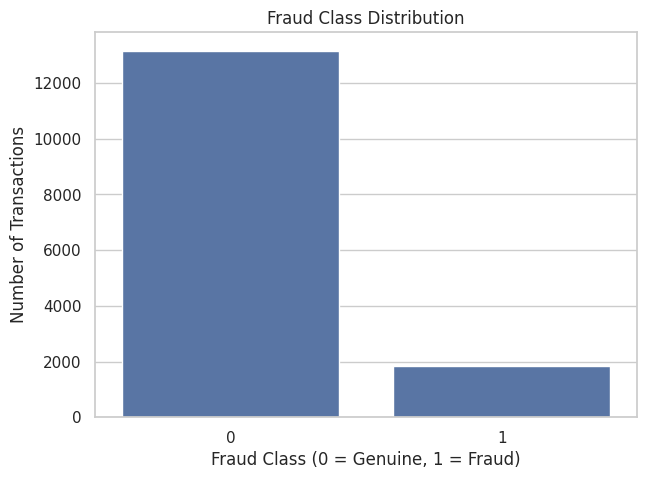

In [80]:
print(df["Is_Fraud"].value_counts())
print("Fraud percentage:", round(df["Is_Fraud"].mean() * 100, 2), "%")

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Is_Fraud")
plt.xlabel("Fraud Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.title("Fraud Class Distribution")
plt.show()

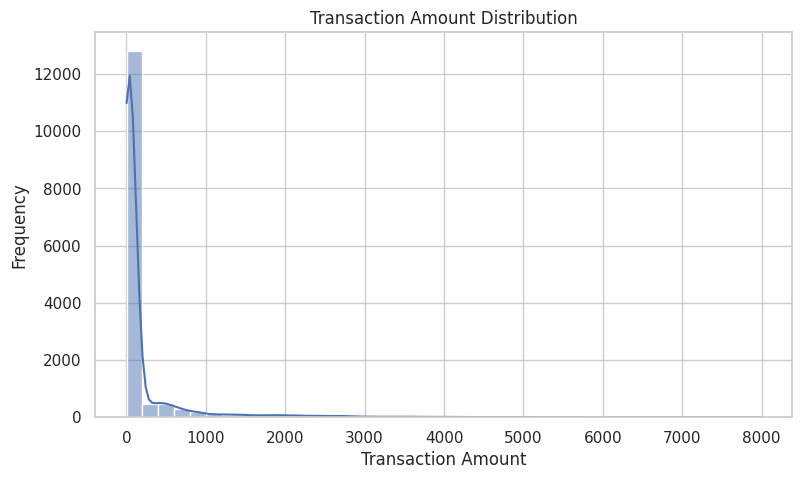

In [81]:
plt.figure(figsize=(9,5))
sns.histplot(df["Amount"], bins=40, kde=True)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.show()

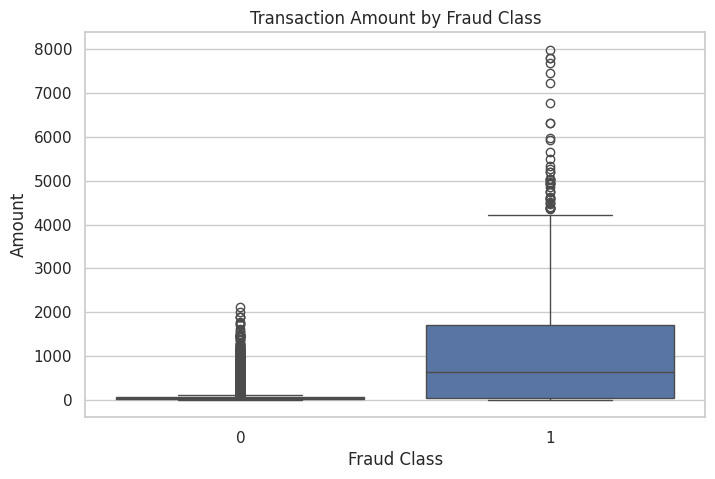

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Is_Fraud", y="Amount")
plt.xlabel("Fraud Class")
plt.ylabel("Amount")
plt.title("Transaction Amount by Fraud Class")
plt.show()

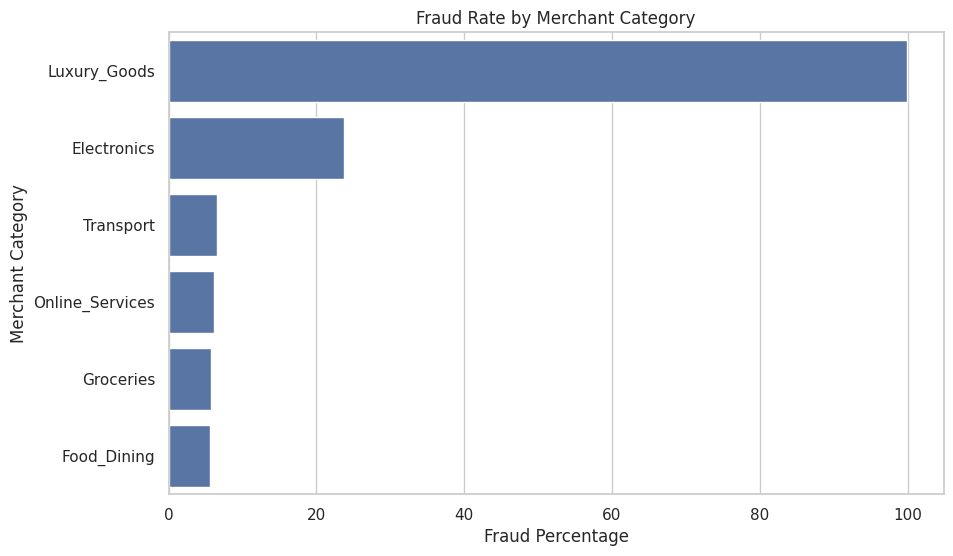

In [83]:
merchant_rate = df.groupby("Merchant_Category")["Is_Fraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=merchant_rate.values * 100, y=merchant_rate.index)
plt.xlabel("Fraud Percentage")
plt.ylabel("Merchant Category")
plt.title("Fraud Rate by Merchant Category")
plt.show()

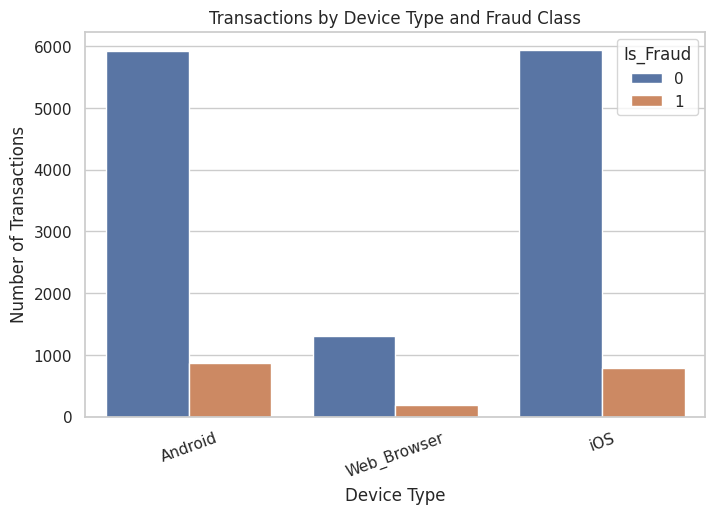

In [84]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Device_Type", hue="Is_Fraud")
plt.xlabel("Device Type")
plt.ylabel("Number of Transactions")
plt.title("Transactions by Device Type and Fraud Class")
plt.xticks(rotation=20)
plt.show()

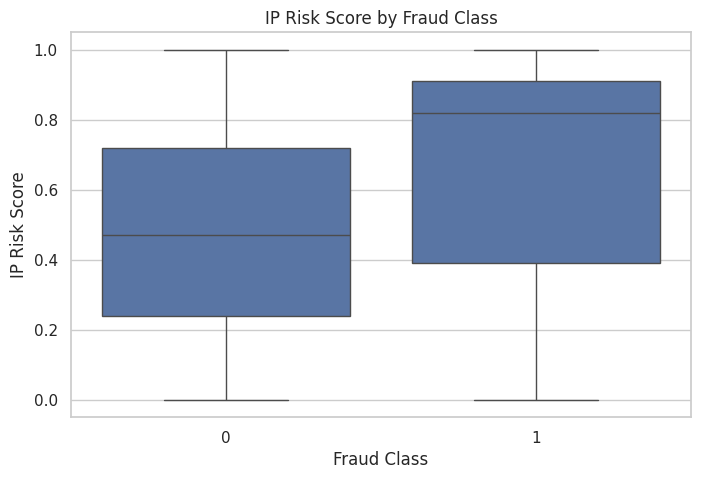

In [85]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Is_Fraud", y="IP_Risk_Score")
plt.xlabel("Fraud Class")
plt.ylabel("IP Risk Score")
plt.title("IP Risk Score by Fraud Class")
plt.show()

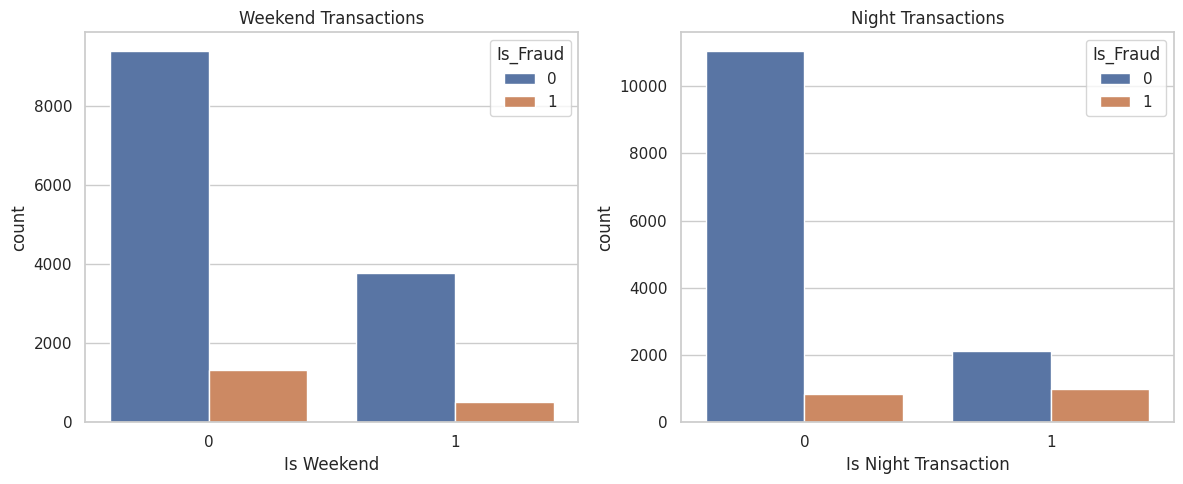

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(data=df, x="Is_Weekend", hue="Is_Fraud", ax=axes[0])
axes[0].set_title("Weekend Transactions")
axes[0].set_xlabel("Is Weekend")

sns.countplot(data=df, x="Is_Night_Transaction", hue="Is_Fraud", ax=axes[1])
axes[1].set_title("Night Transactions")
axes[1].set_xlabel("Is Night Transaction")

plt.tight_layout()
plt.show()

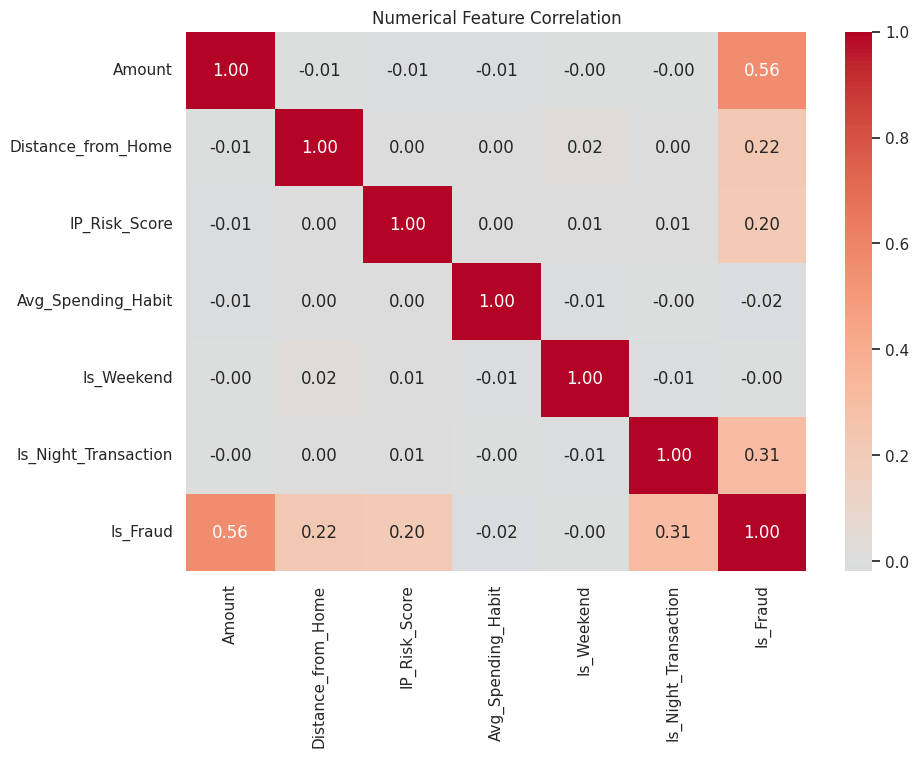

In [87]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numerical Feature Correlation")
plt.show()

In [88]:
numeric_expected = [
    "Amount", "Distance_from_Home", "IP_Risk_Score",
    "Avg_Spending_Habit", "Is_Weekend", "Is_Night_Transaction", "Is_Fraud"
]

for col in numeric_expected:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Standardize categorical text.
for col in ["Merchant_Category", "Device_Type"]:
    df[col] = df[col].astype("string").str.strip()

# Parse timestamp when available.
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

print(df.dtypes)

Transaction_ID                  object
Timestamp               datetime64[ns]
Customer_ID                     object
Amount                         float64
Merchant_Category       string[python]
Distance_from_Home             float64
Device_Type             string[python]
IP_Risk_Score                  float64
Avg_Spending_Habit             float64
Is_Weekend                       int64
Is_Night_Transaction             int64
Is_Fraud                         int64
dtype: object


In [89]:
numeric_cols = [
    "Amount", "Distance_from_Home", "IP_Risk_Score",
    "Avg_Spending_Habit", "Is_Weekend", "Is_Night_Transaction"
]

categorical_cols = ["Merchant_Category", "Device_Type"]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", int(df.isnull().sum().sum()))

Remaining missing values: 0


In [90]:
df = df.drop_duplicates().copy()
print("Shape after duplicate removal:", df.shape)

Shape after duplicate removal: (15000, 12)


In [91]:
feature_columns = [
    "Amount", "Merchant_Category", "Distance_from_Home",
    "Device_Type", "IP_Risk_Score", "Avg_Spending_Habit",
    "Is_Weekend", "Is_Night_Transaction"
]

X = df[feature_columns].copy()
y = df["Is_Fraud"].astype(int).copy()

print("Features:", feature_columns)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['Amount', 'Merchant_Category', 'Distance_from_Home', 'Device_Type', 'IP_Risk_Score', 'Avg_Spending_Habit', 'Is_Weekend', 'Is_Night_Transaction']
X shape: (15000, 8)
y shape: (15000,)


In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
print("Training class distribution:")
print(y_train.value_counts())

Training rows: 12000
Testing rows : 3000
Training class distribution:
Is_Fraud
0    10532
1     1468
Name: count, dtype: int64


In [93]:
numeric_features = [
    "Amount", "Distance_from_Home", "IP_Risk_Score",
    "Avg_Spending_Habit", "Is_Weekend", "Is_Night_Transaction"
]
categorical_features = ["Merchant_Category", "Device_Type"]

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), numeric_features),
    ("cat", encoder, categorical_features)
])

print("MinMaxScaler and OneHotEncoder ready.")

MinMaxScaler and OneHotEncoder ready.


Before SMOTE: Counter({0: 10532, 1: 1468})


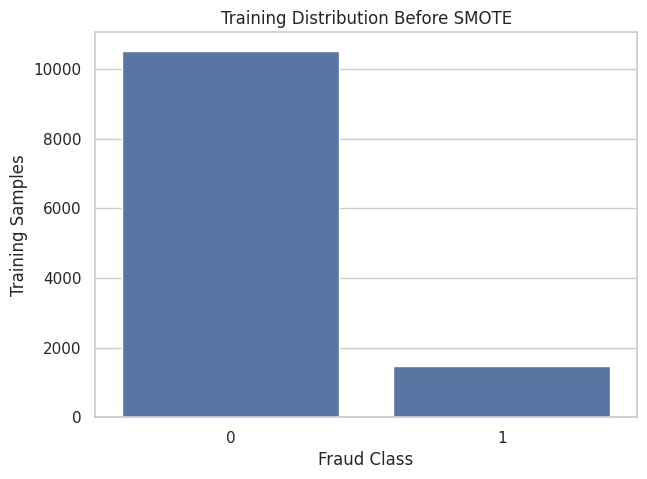

In [94]:
print("Before SMOTE:", Counter(y_train))

plt.figure(figsize=(7,5))
sns.countplot(x=y_train)
plt.xlabel("Fraud Class")
plt.ylabel("Training Samples")
plt.title("Training Distribution Before SMOTE")
plt.show()

In [95]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    )
}

try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
except ImportError:
    print("XGBoost is not installed. Other models will still run.")

print(list(models.keys()))

['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


In [96]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

print("Pipeline order: preprocessing -> SMOTE -> model")

Pipeline order: preprocessing -> SMOTE -> model


In [97]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_rows = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC_AUC": scores["test_roc_auc"].mean(),
        "PR_AUC": scores["test_pr_auc"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(cv_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.9970,0.9819,0.9939,0.9878,0.9999,0.9993
1,Decision Tree,0.9952,0.9739,0.9877,0.9807,0.9919,0.9696
2,Random Forest,0.9947,0.9725,0.9843,0.9783,0.9995,0.9978
3,Logistic Regression,0.9548,0.7342,0.9891,0.8426,0.9943,0.9540


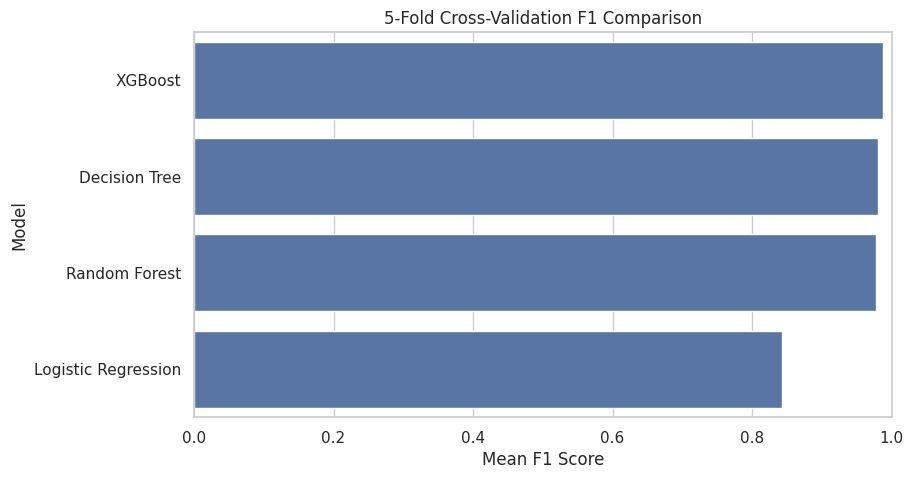

In [99]:
plt.figure(figsize=(9,5))
sns.barplot(data=cv_results, x="F1", y="Model")
plt.xlim(0,1)
plt.xlabel("Mean F1 Score")
plt.title("5-Fold Cross-Validation F1 Comparison")
plt.show()

In [100]:
best_model_name = cv_results.iloc[0]["Model"]
best_pipeline = pipelines[best_model_name]

print("Selected model:", best_model_name)
print("Selection criterion: highest mean 5-Fold CV F1 score")

Selected model: XGBoost
Selection criterion: highest mean 5-Fold CV F1 score


In [101]:
best_pipeline.fit(X_train, y_train)
print("Final pipeline trained successfully.")

Final pipeline trained successfully.


In [102]:
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:,1]

print("Predictions generated for the untouched test set.")

Predictions generated for the untouched test set.


In [103]:
test_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_prob),
        average_precision_score(y_test, y_prob)
    ]
})

display(test_metrics.round(4))

,Metric,Score
0,Accuracy,0.9960
1,Precision,0.9733
2,Recall,0.9946
3,F1,0.9838
4,ROC_AUC,0.9999
5,PR_AUC,0.9993


In [104]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Genuine", "Fraud"],
    zero_division=0
))

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00      2633
       Fraud       0.97      0.99      0.98       367

    accuracy                           1.00      3000
   macro avg       0.99      1.00      0.99      3000
weighted avg       1.00      1.00      1.00      3000



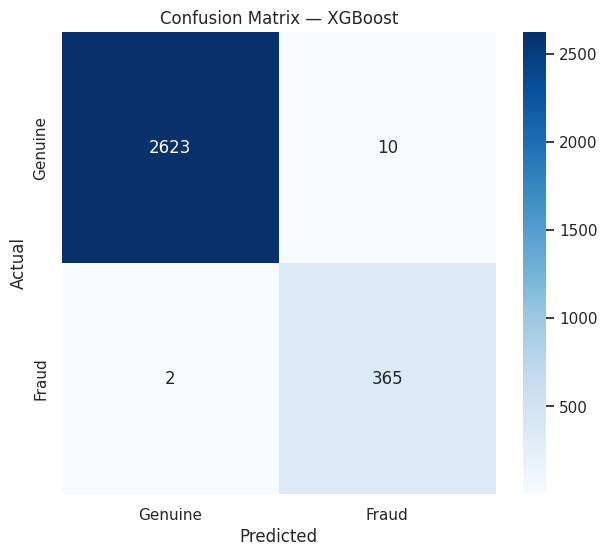

In [105]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

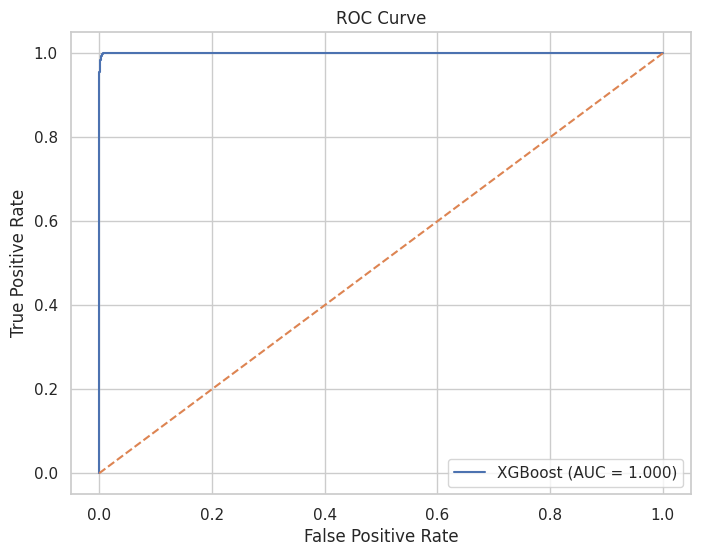

In [106]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

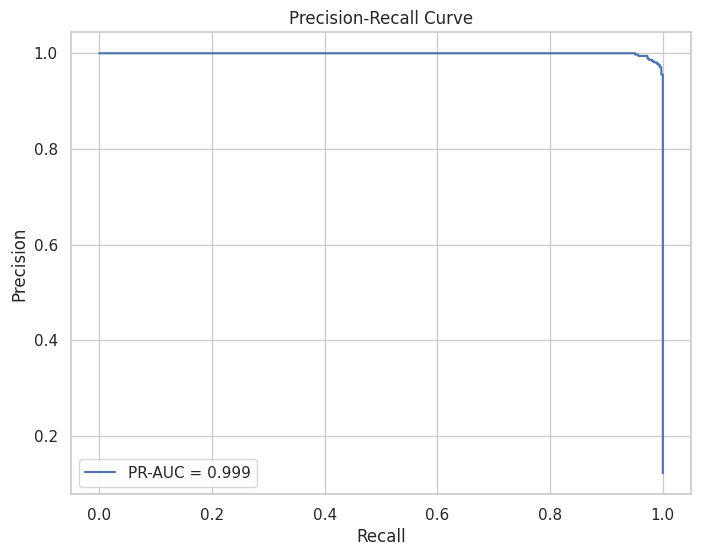

In [107]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

,Feature,Importance
5,num__Is_Night_Transaction,0.278423
9,cat__Merchant_Category_Luxury_Goods,0.227374
1,num__Distance_from_Home,0.159405
2,num__IP_Risk_Score,0.104034
0,num__Amount,0.086603
6,cat__Merchant_Category_Electronics,0.062310
11,cat__Merchant_Category_Transport,0.025406
10,cat__Merchant_Category_Online_Services,0.021541
7,cat__Merchant_Category_Food_Dining,0.011217
3,num__Avg_Spending_Habit,0.007401


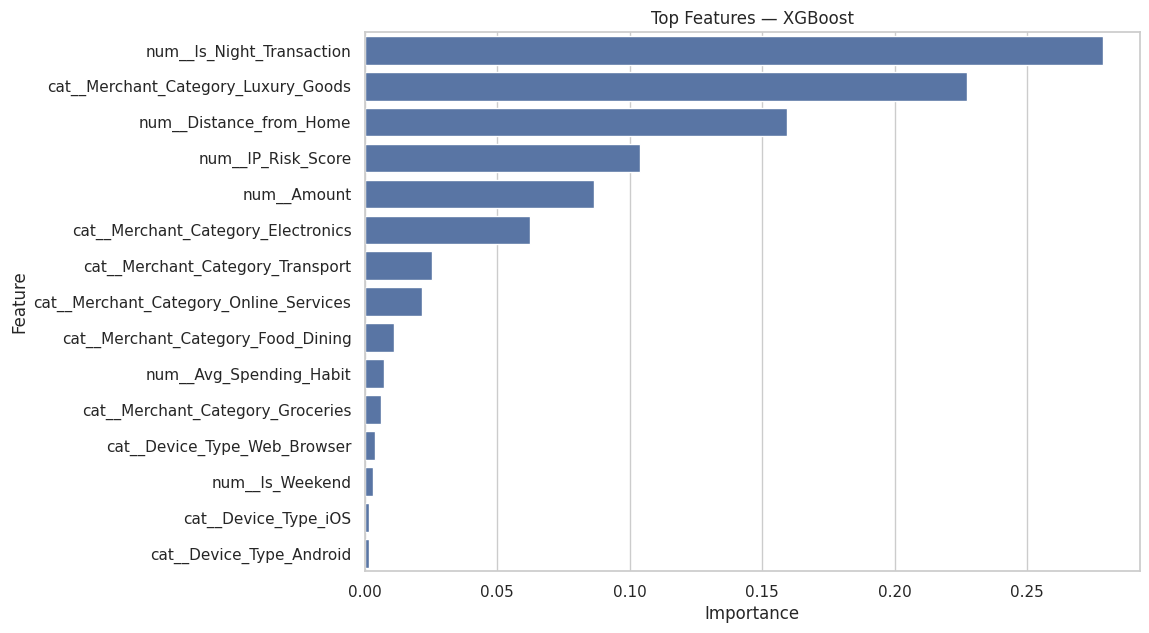

In [108]:
try:
    fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
    fitted_model = best_pipeline.named_steps["model"]
    feature_names = fitted_preprocessor.get_feature_names_out()

    if hasattr(fitted_model, "feature_importances_"):
        importance = fitted_model.feature_importances_
    elif hasattr(fitted_model, "coef_"):
        importance = np.abs(fitted_model.coef_[0])
    else:
        importance = None

    if importance is not None:
        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance
        }).sort_values("Importance", ascending=False).head(15)

        display(importance_df)

        plt.figure(figsize=(10,7))
        sns.barplot(data=importance_df, x="Importance", y="Feature")
        plt.title(f"Top Features — {best_model_name}")
        plt.show()
    else:
        print("Feature importance is not directly available for this model.")
except Exception as e:
    print("Could not calculate feature importance:", e)

In [109]:
prediction_df = X_test.copy()
prediction_df["Actual_Fraud"] = y_test.values
prediction_df["Predicted_Fraud"] = y_pred
prediction_df["Fraud_Probability"] = y_prob

display(prediction_df.sort_values("Fraud_Probability", ascending=False).head(10))

,Amount,Merchant_Category,Distance_from_Home,Device_Type,IP_Risk_Score,Avg_Spending_Habit,Is_Weekend,Is_Night_Transaction,Actual_Fraud,Predicted_Fraud,Fraud_Probability
14732,2510.75,Luxury_Goods,4.8088,Android,0.83,79.78,0,1,1,1,0.999939
11699,36.03,Food_Dining,4.8088,Android,0.82,61.26,1,1,1,1,0.999937
6106,27.98,Groceries,4.8088,iOS,0.90,127.71,0,1,1,1,0.999936
8034,72.80,Groceries,4.8088,Android,0.98,105.66,0,1,1,1,0.999935
6007,3010.21,Luxury_Goods,0.0123,iOS,0.82,87.92,0,1,1,1,0.999934
1384,50.01,Food_Dining,4.8088,iOS,0.93,96.93,0,1,1,1,0.999932
9439,9.61,Transport,4.8088,iOS,0.83,66.29,0,1,1,1,0.999931
8839,14.28,Transport,4.8088,Android,0.83,96.97,1,1,1,1,0.999931
13305,39.51,Groceries,4.8088,iOS,0.95,132.78,0,1,1,1,0.999929
3373,2000.29,Luxury_Goods,0.0123,Android,0.83,106.02,0,1,1,1,0.999929


In [110]:
import joblib

joblib.dump(best_pipeline, "final_fraud_detection_model.pkl")
print("Saved: final_fraud_detection_model.pkl")

Saved: final_fraud_detection_model.pkl


In [111]:
print("="*60)
print("FINAL FRAUD DETECTION MODEL")
print("="*60)
print("Dataset shape:", df.shape)
print("Features used:", len(feature_columns))
print("Selected model:", best_model_name)
print("Cross-validation results:")
display(cv_results.round(4))
print("Final test results:")
display(test_metrics.round(4))

FINAL FRAUD DETECTION MODEL
Dataset shape: (15000, 12)
Features used: 8
Selected model: XGBoost
Cross-validation results:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.9970,0.9819,0.9939,0.9878,0.9999,0.9993
1,Decision Tree,0.9952,0.9739,0.9877,0.9807,0.9919,0.9696
2,Random Forest,0.9947,0.9725,0.9843,0.9783,0.9995,0.9978
3,Logistic Regression,0.9548,0.7342,0.9891,0.8426,0.9943,0.9540


Final test results:


,Metric,Score
0,Accuracy,0.9960
1,Precision,0.9733
2,Recall,0.9946
3,F1,0.9838
4,ROC_AUC,0.9999
5,PR_AUC,0.9993


In [114]:
print("=" * 55)
print("       REAL-TIME FRAUD PREDICTION")
print("=" * 55)

amount = float(input("Transaction Amount: "))
merchant_category = input("Merchant Category: ")
distance_from_home = float(input("Distance From Home: "))
device_type = input("Device Type: ")
ip_risk_score = float(input("IP Risk Score (0-1): "))
avg_spending_habit = float(input("Average Spending Habit: "))
is_weekend = int(input("Is Weekend? (0 = No, 1 = Yes): "))
is_night = int(input("Is Night Transaction? (0 = No, 1 = Yes): "))

runtime_input = pd.DataFrame({
    "Amount": [amount],
    "Merchant_Category": [merchant_category],
    "Distance_from_Home": [distance_from_home],
    "Device_Type": [device_type],
    "IP_Risk_Score": [ip_risk_score],
    "Avg_Spending_Habit": [avg_spending_habit],
    "Is_Weekend": [is_weekend],
    "Is_Night_Transaction": [is_night]
})

prediction = best_pipeline.predict(runtime_input)[0]
probability = best_pipeline.predict_proba(runtime_input)[0][1]

print("\n" + "=" * 55)
print("             PREDICTION RESULT")
print("=" * 55)

print(f"Fraud Probability : {probability * 100:.2f}%")

if prediction == 1:
    print("Prediction : FRAUD TRANSACTION")
else:
    print("Prediction : GENUINE TRANSACTION")

print("=" * 55)

       REAL-TIME FRAUD PREDICTION
Transaction Amount: 1985.97
Merchant Category: Luxury_Goods
Distance From Home: 850
Device Type: Android
IP Risk Score (0-1): 0.89
Average Spending Habit: 94.75
Is Weekend? (0 = No, 1 = Yes): 1
Is Night Transaction? (0 = No, 1 = Yes):  1

             PREDICTION RESULT
Fraud Probability : 99.99%
Prediction : FRAUD TRANSACTION


In [ ]:
import joblib
joblib.dump(best_pipeline, "final_fraud_detection_model.pkl")
print("✅ Model saved: final_fraud_detection_model.pkl")